## Reproducing Azad zero friction evolution

In [4]:
import qtensor.states as states 
import qtensor.operators as ops
import qtensor.simulation.finiteTDVP as sim
import qtensor.simulation.updatemethod as methods
import qtensor.visualise as vis
import copy

N = 8
D = 16
initial_state = states.spin_up(N, D)
# initial_state = states.random(N, 2, D, seed=1)
# initial_state.left_orthogonal()
# initial_state.centralize(N//2 + 1)

# Azad params (-1, -0.5, 1.05)
J = -1
h = -0.5
g = 1.05
H = ops.tilted_ising(J, h, g, N)
H_terms = ops.extensive_as_terms(H)
Hx = ops.tilted_ising(0, 0, 1, N)
Hx_terms = ops.extensive_as_terms(Hx)
Hz = ops.tilted_ising(0, 1, 0, N)
Hz_terms = ops.extensive_as_terms(Hz)

t_final = 10
steps = 1000
epsilon = 1e-5
max_iters = 8

method_l = methods.lanczos_method(epsilon=epsilon, max_iters=max_iters)
method_e = methods.exact_method()

In [5]:
state = copy.deepcopy(initial_state)
state_hist, expecs = sim.tdvp(state, H, t_final, steps, 
                              method=method_l,
                              history=True,
                              )


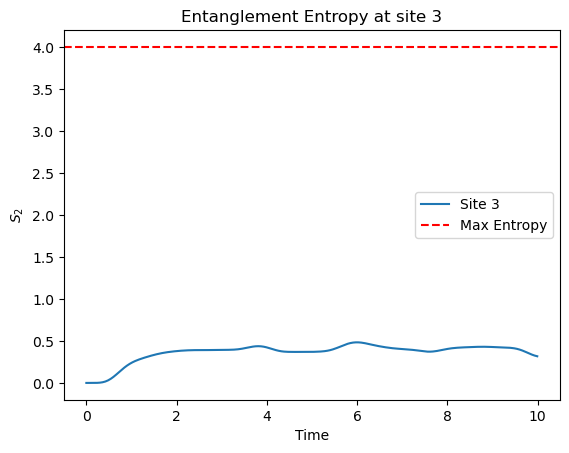

In [6]:
ents, times = vis.plot_entropy_evolution(state_hist, N//2 -1, block_len=3, show_max=True)


Max possible entropy for bond dimension 8: 3.0
Max possible entropy for bond dimension 16: 4.0
Max possible entropy for bond dimension 32: 5.0
Max possible entropy for bond dimension 64: 6.0


Text(0.5, 1.0, 'Partite Renyi entropy of random state')

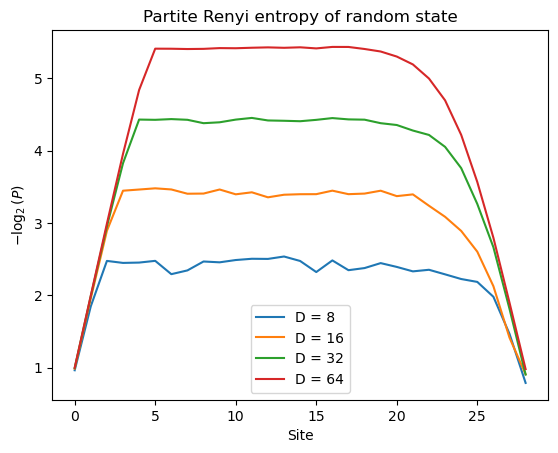

In [11]:
# Check entropy of a random state
import numpy as np
import qtensor.states as states 
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,1)

L=30

for D in [8, 16, 32, 64]:
    random_state = states.unitary_random(L, 2, D, seed=2)
    # random_state.right_orthogonal()
    # random_state.left_orthogonal()
    # random_state.centralize(L//2)
    entropies = []
    for site in sorted(random_state.sites)[:-1]:
        ent = states.entropy(random_state, site)
        # print(f"Site: {site} ; Entropy: {ent}")
        entropies.append(ent)
    print(f"Max possible entropy for bond dimension {D}:", np.log2(D))
    ax.plot(sorted(random_state.sites)[:-1], entropies, label=f"D = {D}")
ax.legend()
ax.set_xlabel('Site')
ax.set_ylabel(r'$-\log _2(P)$')
ax.set_title('Partite Renyi entropy of random state')

In [8]:
random_state[1].shape

(2, 2, 4)

AttributeError: module 'qtensor.states' has no attribute 'sites'

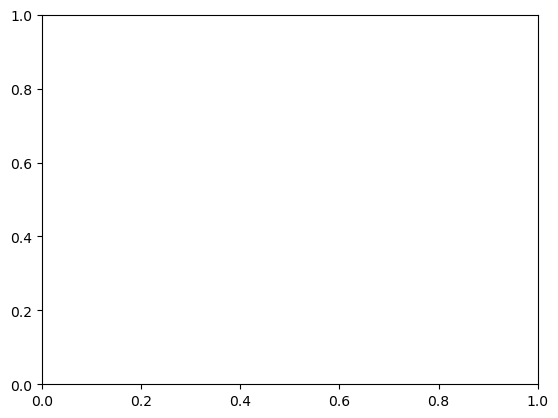

In [ ]:
# Check entropy of a random state
import numpy as np
import qtensor.states as states 
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,1)

N=32
for D in [8, 16, 32, 64]:
    random_state = states.random(N, 2, D, seed=2)
    # random_state.right_orthogonal()
    # random_state.left_orthogonal()
    entropies = states.entropies(states)
    print(f"Max possible entropy for bond dimension {D}:", np.log2(D))
    ax.plot(sorted(random_state.sites)[:-1], entropies, label=f"D = {D}")
ax.legend()
ax.set_xlabel('Site')
ax.set_ylabel(r'$-\log _2(P)$')
ax.set_title('Partite Renyi entropy of random state')

## Comparing different Lanczos parameters



In [ ]:
import qtensor.states as states 
import qtensor.operators as ops
import qtensor.simulation.finiteTDVP as sim
import qtensor.simulation.updatemethod as methods
import qtensor.visualise as vis
import matplotlib.pyplot as plt
import copy

N = 16
D = 128
initial_state = states.spin_up(N, D)

# Azad params (-1, -0.5, 1.05)
J = -1
h = -0.5
g = 1.05
H = ops.tilted_ising(J, h, g, N)
H_terms = ops.extensive_as_terms(H)
Hx = ops.tilted_ising(0, 0, 1, N)
Hx_terms = ops.extensive_as_terms(Hx)
Hz = ops.tilted_ising(0, 1, 0, N)
Hz_terms = ops.extensive_as_terms(Hz)

Hz_mid = Hz_terms[N//2]

t_final = 3
steps = 30

In [ ]:
epsilon = 1e-5
iters = [4, 8, 16, 32]
centre_e = {}

fig, ax = plt.subplots(1,1)

for m in iters:
    max_iters = m
    method_l = methods.lanczos_method(epsilon=epsilon, max_iters=max_iters)
    state = copy.deepcopy(initial_state)
    state_hist, expecs = sim.tdvp(state, H, t_final, steps, 
                                method=method_l,
                                history=True,
                                )
    es = []
    for t in state_hist:
        es.append(ops.local_expect(state_hist[t], Hz_mid))
    centre_e[m] = es
    ax.plot(state_hist.keys(), es)



### Testing entropy issues

In [ ]:
import qtensor.states as states
import numpy as np

# Bell pair as an mps
Ml = np.zeros((2,1,2))
Ml[0, 0, :] = np.array([1, 0])
Ml[1, 0, :] = np.array([0, 1])
Mr = np.transpose(Ml, [0, 2, 1]) * (1/np.sqrt(2))
bell = states.mps([Ml, Mr])
print(f"Bell pair Renyi entropy: {states.entropy(bell)}")

Bell pair Renyi entropy: 0.9999999999999993


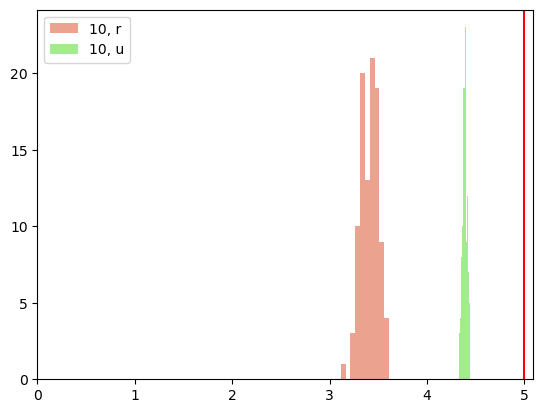

In [3]:
# Sampling random states
import qtensor.states as states
import numpy as np
import matplotlib.pyplot as plt
import copy
fig, ax = plt.subplots(1,1)
 
L = 20
D = 32
d = 2
seeds = np.arange(100)

csite = L//2 - 1

max_ent = np.min([np.log2(D), np.log2(d**(L//2))])

for site in [csite]:
    ents_u=[]
    ents_r=[]
    bad_states = {}
    bad_diag = {}
    for seed in seeds:
        psi_u = states.unitary_random(L, d, D, seed)
        psi_r = states.random(L, d, D, seed)
        # ent_diag = states.entropy_diagonal(psi, site)
        ent_u = states.entropy(psi_u, site)
        ent_r = states.entropy(psi_r, site)
        ents_u.append(ent_u)
        ents_r.append(ent_r)
        # ents_diag.append(ent_diag)
        # if ent > max_ent:
        #     print(f'{ent} > {max_ent}')
        #     bad_states[seed] = copy.deepcopy(psi)
        #     print(f"Some bs happening for seed {seed}")
        # if ent_diag > max_ent:
        #     print(f'{ent_diag} > {max_ent}')
        #     bad_states[seed] = copy.deepcopy(psi)
        #     print(f"Some bs happening with diag for seed {seed}")

    ax.hist(ents_r, 10, color=(0.9, 1 - site/L, site/L, 0.8), label=f'{site+1}, r')
    ax.hist(ents_u, 10, color=(1 - site/L, 0.9, site/L, 0.8), label=f'{site+1}, u')

ax.axvline(max_ent, c='r')
ax.set_xlim(0)
ax.legend()



In [3]:
print(f'Normal ents:\n{[states.entropy(bad_states[seed], site) for seed in bad_states]}')
print(f'Diag ents:\n{[states.entropy_diagonal(bad_states[seed], site) for seed in bad_states]}')


Normal ents:
[]
Diag ents:
[]


In [63]:

seed = 8
psi = states.random(L, d, D, seed)
ent_diag = states.entropy_diagonal(psi, site)
print(f'Seed = {seed} ; ent_diag={ent_diag}')
# Does entropy change after 

Seed = 8 ; ent_diag=2.845775903204293


In [1]:
import qtensor.states as states

L = 35
d = 2
D = 6
seed = 42
psi = states.unitary_random(L, d, D, seed)
psi.shapes()
psi.right_orthogonal()
psi.shapes()

1---2---4---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---1
  |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 
  2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2 
1---2---4---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---6---4---2---1
  |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   |   | 
  2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2   2 
